In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
abalone = fetch_ucirepo(id=1)

# data (as pandas dataframes)
X = abalone.data.features
y = abalone.data.targets

# metadata
print(abalone.metadata)

# variable information
print(abalone.variables)

display(X.head())
display(y.head()) # Added parentheses to call the head method


{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['Rings'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C55C7W', 'creators': ['Warwick Nash', 'Tracy Sellers', 'Simon Talbot', 'Andrew Cawthorn', 'Wes Ford'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- 

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


,Rings
0,15
1,7
2,9
3,10
4,7


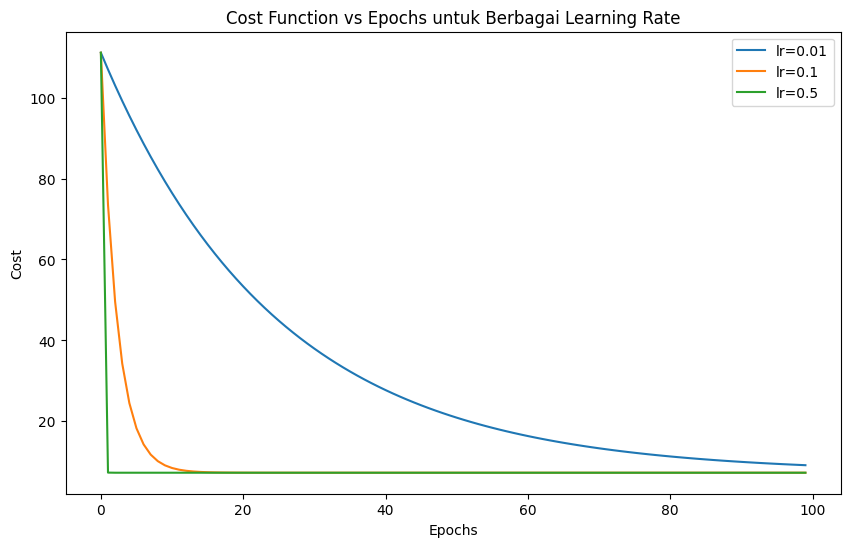

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Load dataset Abalone dari UCI Repository
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
column_names = ['Sex', 'Length', 'Diameter', 'Height', 'WholeWeight', 'ShuckedWeight', 'VisceraWeight', 'ShellWeight', 'Rings']
df = pd.read_csv(data_url, names=column_names)

# Data preprocessing - Gunakan 'Diameter' sebagai X dan 'Rings' sebagai Y
df = df[['Diameter', 'Rings']].dropna()
X = df['Diameter'].values.reshape(-1, 1)
y = df['Rings'].values.reshape(-1, 1)

# # # Normalisasi data
X = (X - np.mean(X)) / np.std(X)
# y = (y - np.mean(y)) / np.std(y)

# Split data (60% training, 40% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Scaler = StandardScaler()
# X_train = Scaler.fit_transform(X_train)
# X_test = Scaler.transform(X_test)

# Eksperimen dengan berbagai learning rate
learning_rates = [0.01, 0.1, 0.5]
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    w, b, cost_history, _, _ = gradient_descent(X_train, y_train, lr, epochs=100)
    plt.plot(range(100), cost_history, label=f'lr={lr}')

plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.legend()
plt.title('Cost Function vs Epochs untuk Berbagai Learning Rate')
plt.show()




##Learning Rate 0.01

Nilai w (slope): 1.8377899455485267
Nilai b (intercept): 9.990851086836626
Mean Squared Error (MSE) - Train Data: 7.303480563084088
Mean Squared Error (MSE) - Test Data: 6.45542106098593


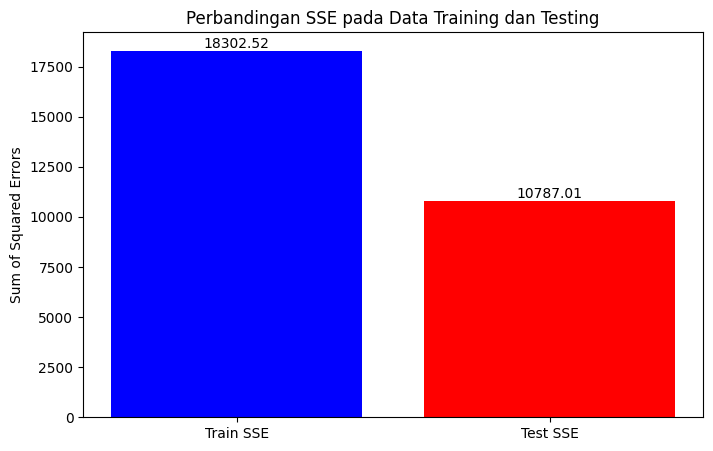

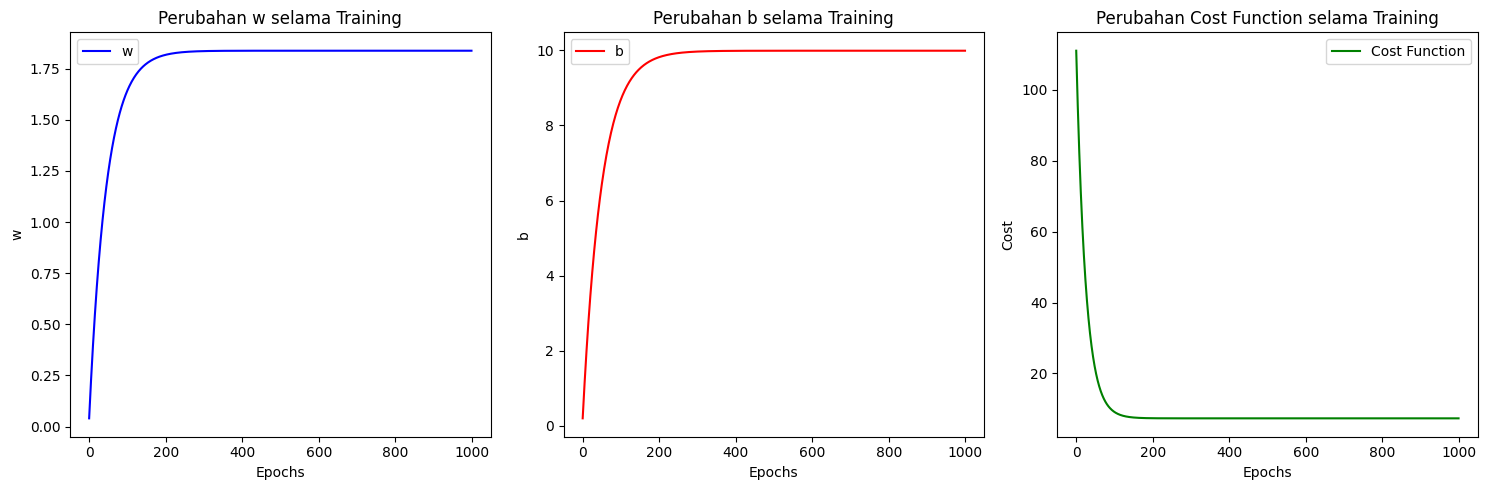

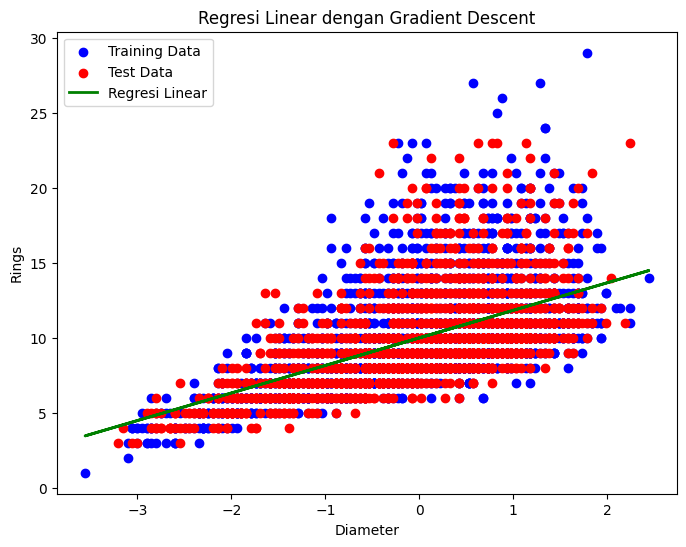

In [ ]:

# Menghitung SSE dan MSE
def calculate_sse(X, y, w, b):
    y_pred = w * X + b
    return np.sum((y - y_pred) ** 2)

def calculate_mse(X, y, w, b):
    y_pred = w * X + b
    return np.mean((y - y_pred) ** 2)

w_opt, b_opt, cost_history, w_history, b_history = gradient_descent(X_train, y_train, lr=0.01, epochs=1000)
SSE_train = calculate_sse(X_train, y_train, w_opt, b_opt)
SSE_test = calculate_sse(X_test, y_test, w_opt, b_opt)
MSE_train = calculate_mse(X_train, y_train, w_opt, b_opt)
MSE_test = calculate_mse(X_test, y_test, w_opt, b_opt)

# Cetak nilai w, b, MSE Train, dan MSE Test
print(f"Nilai w (slope): {w_opt}")
print(f"Nilai b (intercept): {b_opt}")
print(f"Mean Squared Error (MSE) - Train Data: {MSE_train}")
print(f"Mean Squared Error (MSE) - Test Data: {MSE_test}")

# Plot SSE
plt.figure(figsize=(8, 5))
bars = plt.bar(['Train SSE', 'Test SSE'], [SSE_train, SSE_test], color=['blue', 'red'])
plt.ylabel('Sum of Squared Errors')
plt.title('Perbandingan SSE pada Data Training dan Testing')

# Tambahkan nilai di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.show()

# Visualisasi perubahan parameter selama training
epochs = list(range(1000))
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, w_history, label='w', color='blue')
plt.xlabel('Epochs')
plt.ylabel('w')
plt.title('Perubahan w selama Training')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, b_history, label='b', color='red')
plt.xlabel('Epochs')
plt.ylabel('b')
plt.title('Perubahan b selama Training')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, cost_history, label='Cost Function', color='green')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Perubahan Cost Function selama Training')
plt.legend()

plt.tight_layout()
plt.show()

# Plot data dan garis regresi
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.plot(X_train, w_opt * X_train + b_opt, color='green', linewidth=2, label='Regresi Linear')
plt.xlabel('Diameter')
plt.ylabel('Rings')
plt.title('Regresi Linear dengan Gradient Descent')
plt.legend()
plt.show()

##Learning Rate 0.1

Nilai w (slope): 1.8377899433578957
Nilai b (intercept): 9.990851103531412
Mean Squared Error (MSE) - Train Data: 7.303480563084088
Mean Squared Error (MSE) - Test Data: 6.455421065919246


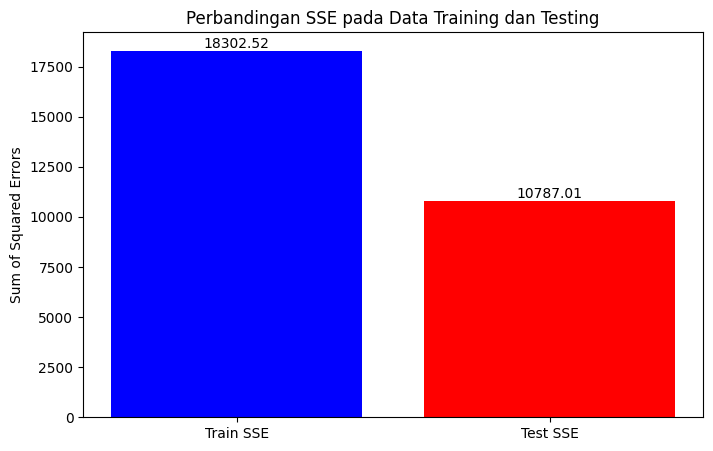

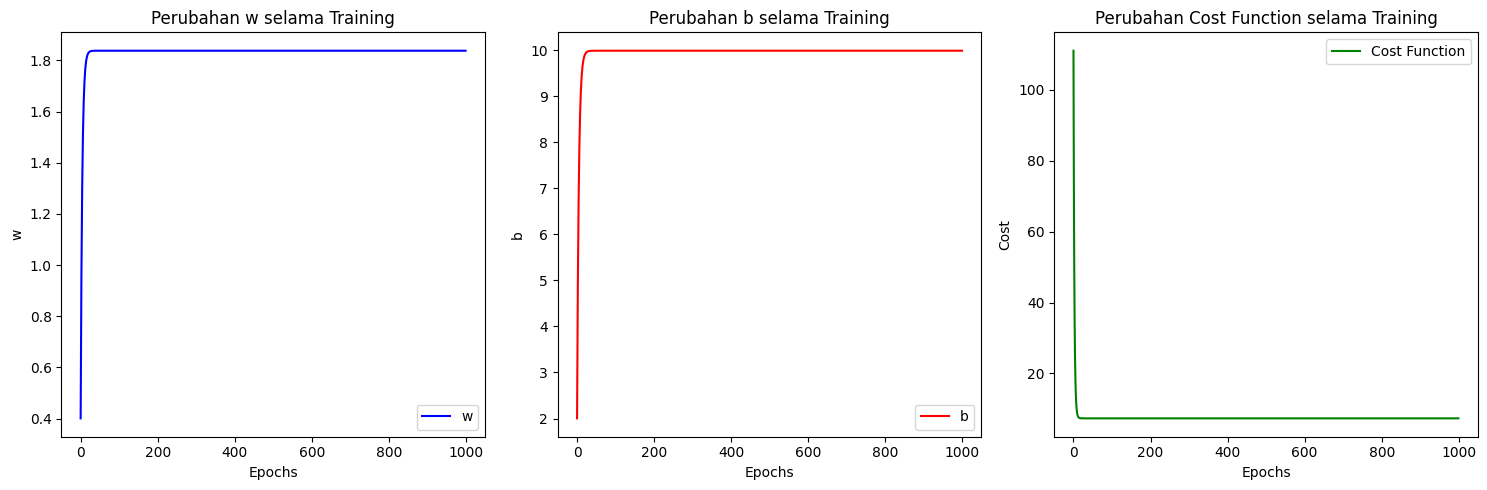

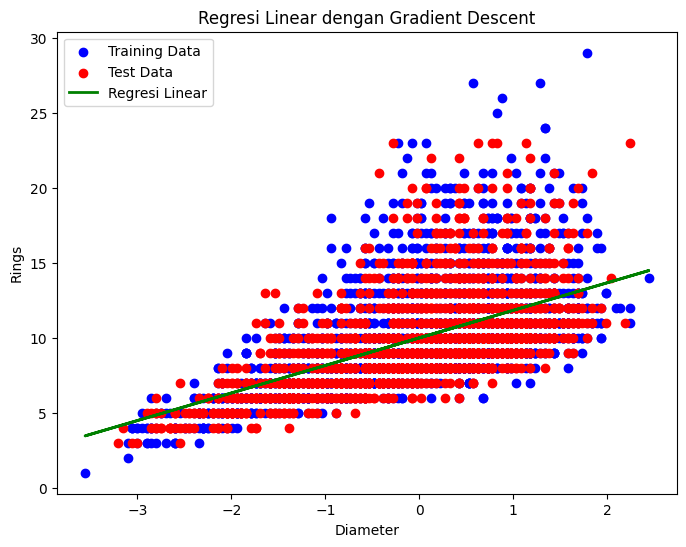

In [ ]:
# Menghitung SSE dan MSE
def calculate_sse(X, y, w, b):
    y_pred = w * X + b
    return np.sum((y - y_pred) ** 2)

def calculate_mse(X, y, w, b):
    y_pred = w * X + b
    return np.mean((y - y_pred) ** 2)

w_opt, b_opt, cost_history, w_history, b_history = gradient_descent(X_train, y_train, lr=0.1, epochs=1000)
SSE_train = calculate_sse(X_train, y_train, w_opt, b_opt)
SSE_test = calculate_sse(X_test, y_test, w_opt, b_opt)
MSE_train = calculate_mse(X_train, y_train, w_opt, b_opt)
MSE_test = calculate_mse(X_test, y_test, w_opt, b_opt)

# Cetak nilai w, b, MSE Train, dan MSE Test
print(f"Nilai w (slope): {w_opt}")
print(f"Nilai b (intercept): {b_opt}")
print(f"Mean Squared Error (MSE) - Train Data: {MSE_train}")
print(f"Mean Squared Error (MSE) - Test Data: {MSE_test}")

# Plot SSE
plt.figure(figsize=(8, 5))
bars = plt.bar(['Train SSE', 'Test SSE'], [SSE_train, SSE_test], color=['blue', 'red'])
plt.ylabel('Sum of Squared Errors')
plt.title('Perbandingan SSE pada Data Training dan Testing')

# Tambahkan nilai di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.show()

# Visualisasi perubahan parameter selama training
epochs = list(range(1000))
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, w_history, label='w', color='blue')
plt.xlabel('Epochs')
plt.ylabel('w')
plt.title('Perubahan w selama Training')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, b_history, label='b', color='red')
plt.xlabel('Epochs')
plt.ylabel('b')
plt.title('Perubahan b selama Training')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, cost_history, label='Cost Function', color='green')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Perubahan Cost Function selama Training')
plt.legend()

plt.tight_layout()
plt.show()

# Plot data dan garis regresi
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.plot(X_train, w_opt * X_train + b_opt, color='green', linewidth=2, label='Regresi Linear')
plt.xlabel('Diameter')
plt.ylabel('Rings')
plt.title('Regresi Linear dengan Gradient Descent')
plt.legend()
plt.show()

##Learning Rate 0.5

Nilai w (slope): 1.837789943357895
Nilai b (intercept): 9.990851103531416
Mean Squared Error (MSE) - Train Data: 7.303480563084086
Mean Squared Error (MSE) - Test Data: 6.455421065919249


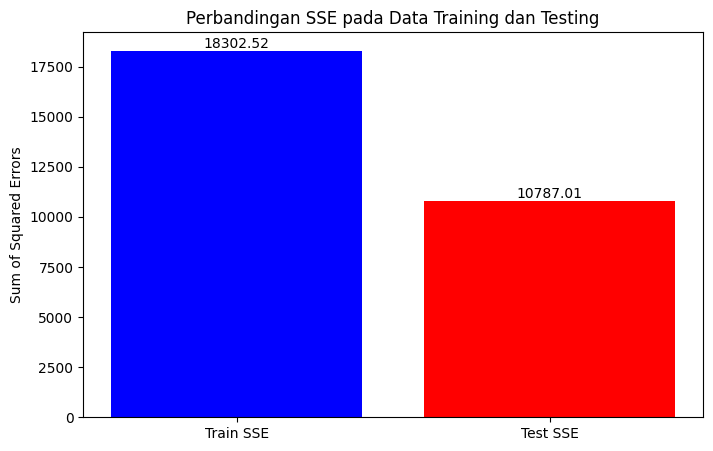

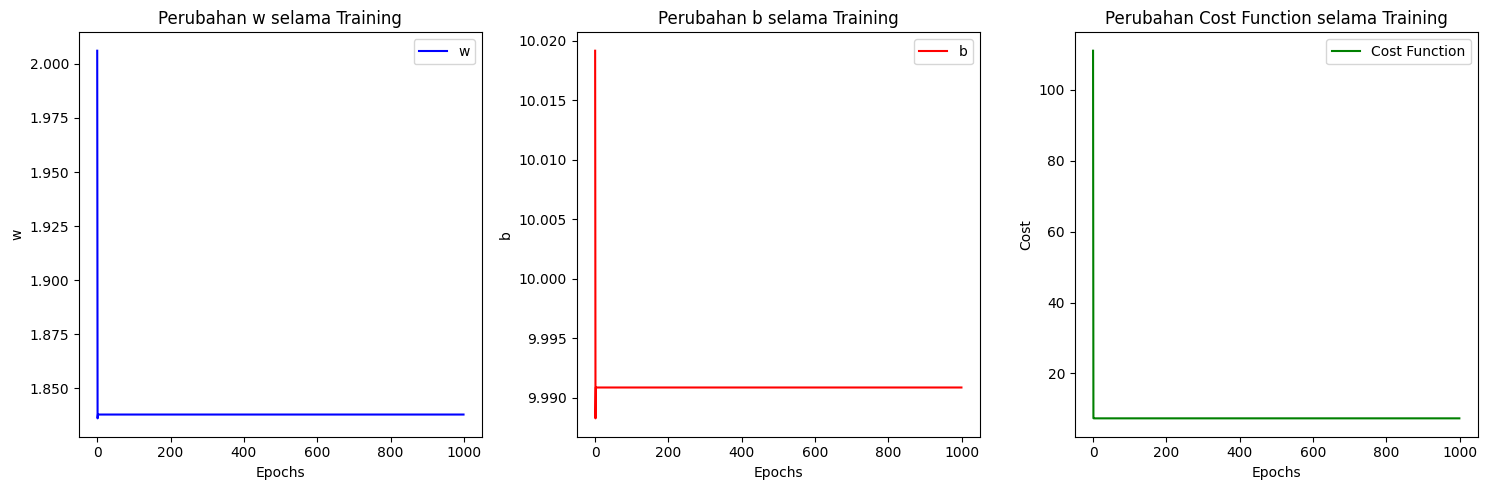

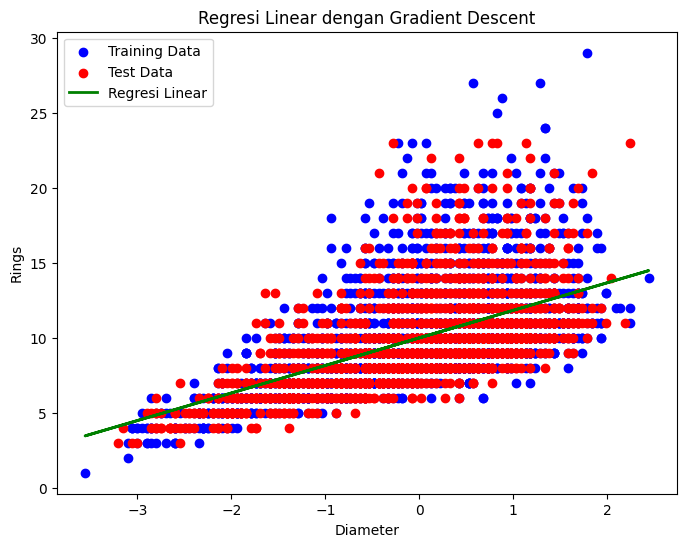

In [ ]:
# Menghitung SSE dan MSE
def calculate_sse(X, y, w, b):
    y_pred = w * X + b
    return np.sum((y - y_pred) ** 2)

def calculate_mse(X, y, w, b):
    y_pred = w * X + b
    return np.mean((y - y_pred) ** 2)

w_opt, b_opt, cost_history, w_history, b_history = gradient_descent(X_train, y_train, lr=0.5, epochs=1000)
SSE_train = calculate_sse(X_train, y_train, w_opt, b_opt)
SSE_test = calculate_sse(X_test, y_test, w_opt, b_opt)
MSE_train = calculate_mse(X_train, y_train, w_opt, b_opt)
MSE_test = calculate_mse(X_test, y_test, w_opt, b_opt)

# Cetak nilai w, b, MSE Train, dan MSE Test
print(f"Nilai w (slope): {w_opt}")
print(f"Nilai b (intercept): {b_opt}")
print(f"Mean Squared Error (MSE) - Train Data: {MSE_train}")
print(f"Mean Squared Error (MSE) - Test Data: {MSE_test}")

# Plot SSE
plt.figure(figsize=(8, 5))
bars = plt.bar(['Train SSE', 'Test SSE'], [SSE_train, SSE_test], color=['blue', 'red'])
plt.ylabel('Sum of Squared Errors')
plt.title('Perbandingan SSE pada Data Training dan Testing')

# Tambahkan nilai di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.show()

# Visualisasi perubahan parameter selama training
epochs = list(range(1000))
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, w_history, label='w', color='blue')
plt.xlabel('Epochs')
plt.ylabel('w')
plt.title('Perubahan w selama Training')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, b_history, label='b', color='red')
plt.xlabel('Epochs')
plt.ylabel('b')
plt.title('Perubahan b selama Training')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, cost_history, label='Cost Function', color='green')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Perubahan Cost Function selama Training')
plt.legend()

plt.tight_layout()
plt.show()

# Plot data dan garis regresi
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.plot(X_train, w_opt * X_train + b_opt, color='green', linewidth=2, label='Regresi Linear')
plt.xlabel('Diameter')
plt.ylabel('Rings')
plt.title('Regresi Linear dengan Gradient Descent')
plt.legend()
plt.show()

##Analisis dan Kesimpulan

### **Analisis Pengaruh Learning Rate terhadap Konvergensi dan Hasil Akhir Model**  

Eksperimen ini menggunakan **learning rate 0.01, 0.1, dan 0.5** untuk melihat dampaknya terhadap **konvergensi model** dalam regresi linear menggunakan **Gradient Descent**. Konvergensi diukur berdasarkan seberapa cepat model menemukan nilai optimal untuk **cost function**.  

Learning rate **0.01** menunjukkan **konvergensi stabil tetapi lambat**, membutuhkan banyak iterasi untuk mencapai titik minimum. Sebaliknya, **0.1** menghasilkan **konvergensi optimal**, dengan cost function yang menurun cepat tanpa osilasi. Namun, **0.5** menunjukkan **ketidakstabilan**, dengan cost function yang naik-turun atau bahkan divergen, membuat model sulit menemukan solusi optimal.  

Dari hasil **Sum of Squared Errors (SSE)**, **learning rate 0.01 memiliki SSE kecil pada training tetapi lebih besar pada testing**, menunjukkan model dapat belajar tetapi lambat. **Learning rate 0.1 memberikan SSE terbaik**, menunjukkan **model tidak overfitting maupun underfitting**. Sebaliknya, **0.5 menghasilkan SSE yang sangat besar**, menandakan model gagal belajar karena osilasi.  

Kesimpulannya, **learning rate 0.1 adalah yang terbaik**, karena **konvergen cepat, stabil, dan memiliki SSE optimal**. Learning rate yang terlalu kecil **butuh banyak iterasi**, sedangkan yang terlalu besar **menyebabkan osilasi atau divergensi**, membuat model sulit menemukan pola yang benar. Oleh karena itu, **pemilihan learning rate yang tepat sangat penting dalam optimasi model dengan Gradient Descent**.